In [1]:
# ============================================
# 6.1 Import Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ============================================
# 6.2 Load Dataset
# ============================================

train_df = pd.read_csv("../data/train.csv")

print(train_df.shape)

train_df.head()

(140700, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [3]:
# ============================================
# 6.3 Create Backup
# ============================================

train = train_df.copy()

print("Backup Created")

Backup Created


In [4]:
# ============================================
# 6.4 Drop Unnecessary Columns
# ============================================

train.drop(
    columns=["id", "Name"],
    inplace=True
)

print("Columns Removed")

Columns Removed


In [5]:
# ============================================
# 6.5 Separate Columns
# ============================================

numerical_columns = train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns.remove("Depression")

print(numerical_columns)

print(categorical_columns)

['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [6]:
# ============================================
# 6.6 Handle Missing Values
# ============================================

num_imputer = SimpleImputer(
    strategy="median"
)

train[numerical_columns] = num_imputer.fit_transform(
    train[numerical_columns]
)

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

train[categorical_columns] = cat_imputer.fit_transform(
    train[categorical_columns]
)

print("Missing Values Handled")

Missing Values Handled


In [7]:
# ============================================
# 6.7 Encode Categorical Features
# ============================================

label_encoders = {}

for column in categorical_columns:

    train[column] = train[column].astype(str)

    le = LabelEncoder()

    train[column] = le.fit_transform(
        train[column]
    )

    label_encoders[column] = le

print("Encoding Completed")

Encoding Completed


In [8]:
# ============================================
# 6.8 Feature Target Split
# ============================================

X = train.drop(
    "Depression",
    axis=1
)

y = train["Depression"]

print(X.shape)
print(y.shape)

(140700, 17)
(140700,)


In [9]:
# ============================================
# 6.9 Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(112560, 17)
(28140, 17)


In [10]:
# ============================================
# 6.10 Feature Scaling
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [11]:
# ============================================
# 6.11 Create Models
# ============================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "SVM": SVC()
}

print("Models Ready")

Models Ready


In [12]:
# ============================================
# 6.12 Train and Evaluate Models
# ============================================

results = []

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # Store Results
    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1
    })

    print(f"{name} Completed")

Logistic Regression Completed
Decision Tree Completed
Random Forest Completed
Gradient Boosting Completed
SVM Completed


In [13]:
# ============================================
# 6.13 Results DataFrame
# ============================================

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.937527,0.844668,0.804029,0.823848
1,Decision Tree,0.900462,0.722479,0.734207,0.728296
2,Random Forest,0.936567,0.846090,0.795619,0.820079
3,Gradient Boosting,0.937100,0.843435,0.802855,0.822645
4,SVM,0.937171,0.852774,0.790730,0.820580


In [14]:
# ============================================
# 6.14 Add Deep Learning Result
# ============================================

deep_learning_result = pd.DataFrame([{

    "Model": "Deep Learning",

    "Accuracy": 0.935217,

    "Precision": 0.821918,

    "Recall": 0.821436,

    "F1 Score": 0.821677
}])

results_df = pd.concat(
    [results_df, deep_learning_result],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.937527,0.844668,0.804029,0.823848
1,Decision Tree,0.900462,0.722479,0.734207,0.728296
2,Random Forest,0.936567,0.846090,0.795619,0.820079
3,Gradient Boosting,0.937100,0.843435,0.802855,0.822645
4,SVM,0.937171,0.852774,0.790730,0.820580
5,Deep Learning,0.935217,0.821918,0.821436,0.821677


In [15]:
# ============================================
# 6.15 Best Model
# ============================================

best_model = results_df.sort_values(

    by="F1 Score",

    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.937527,0.844668,0.804029,0.823848
3,Gradient Boosting,0.937100,0.843435,0.802855,0.822645
5,Deep Learning,0.935217,0.821918,0.821436,0.821677
4,SVM,0.937171,0.852774,0.790730,0.820580
2,Random Forest,0.936567,0.846090,0.795619,0.820079
1,Decision Tree,0.900462,0.722479,0.734207,0.728296


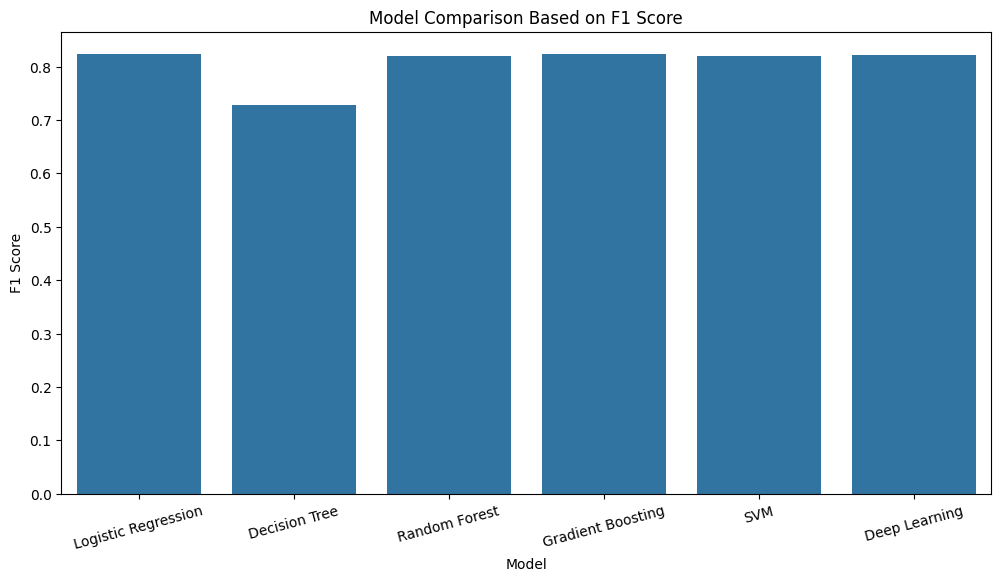

In [16]:
# ============================================
# 6.16 Model Comparison Graph
# ============================================

plt.figure(figsize=(12,6))

sns.barplot(

    x="Model",

    y="F1 Score",

    data=results_df
)

plt.xticks(rotation=15)

plt.title("Model Comparison Based on F1 Score")

plt.show()

# ============================================
# Final Observation
# ============================================

print("""

Final Observations:

- Logistic Regression achieved the highest
  F1 Score among all models.

- Deep Learning model also performed well
  with competitive Accuracy and Recall.

- Traditional Machine Learning models and
  Deep Learning models produced similar
  performance on this dataset.

- Since the project requirement focuses on
  Deep Learning using PyTorch, the Deep
  Learning model is selected as the final
  deployment model.

- The final model provides balanced
  performance for depression prediction.

""")

In [17]:
print("Model Comparison Completed Successfully")

Model Comparison Completed Successfully
